In [52]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
?autoreload

Docstring:
::

  %autoreload [-p] [-l] [--hide-errors] [--full] [mode]

%autoreload => Reload modules automatically

%autoreload or %autoreload now
Reload all modules (except those excluded by %aimport) automatically
now.

%autoreload 0 or %autoreload off
Disable automatic reloading.

%autoreload 1 or %autoreload explicit
Reload only modules imported with %aimport every time before executing
the Python code typed.

%autoreload 2 or %autoreload all
Reload all modules (except those excluded by %aimport) every time
before executing the Python code typed.

%autoreload 3 or %autoreload complete
Same as 2/all, but also but also adds any new objects in the module. See
unit test at IPython/extensions/tests/test_autoreload.py::test_autoload_newly_added_objects

The optional arguments --print and --log control display of autoreload activity. The default
is to act silently; --print (or -p) will print out the names of modules that are being
reloaded, and --log (or -l) outputs them to the log at IN

In [54]:
%autoreload now

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import numpy as np
from scipy.ndimage import gaussian_filter1d
import cv2
import matplotlib.pyplot as plt

In [56]:
np.empty((1200, 1600, 1)).squeeze().shape

(1200, 1600)

In [57]:
import numpy as np
import random

from BloodCellDataset import slice_dataset, BloodCellDataset, PATCH_SIZE

np.random.seed(0)
random.seed(0)

# TODO: return original labeled images (size doesn't matter)
bg_patches, cell_data, bg_masks, labeled_orig, orig_size = slice_dataset(
    train_dir="train",
    sample_size=100,
    # sample_size=2048,
    patch_size=PATCH_SIZE,
)

Slicing dataset: 100%|██████████| 100/100 [00:08<00:00, 12.20it/s]

Extracted 8887 background patches and 6050 cells


In [58]:
labeled_orig[0]

(array([[ 90,  96,  84, ..., 234, 234, 236],
        [120, 107,  98, ..., 234, 234, 236],
        [155, 130, 109, ..., 234, 234, 236],
        ...,
        [226, 226, 226, ..., 219, 239, 247],
        [228, 228, 228, ..., 219, 239, 247],
        [225, 228, 228, ..., 219, 233, 244]],
       shape=(1200, 1600), dtype=uint8),
 85,
 [(0.810625, 0.9725, 0.06, 0.055),
  (0.875, 0.9641666666666666, 0.056875, 0.07166666666666667),
  (0.04625, 0.9616666666666667, 0.058125, 0.07666666666666666),
  (0.466875, 0.96, 0.069375, 0.08),
  (0.19125, 0.9591666666666666, 0.06875, 0.08083333333333333),
  (0.384375, 0.9533333333333334, 0.058125, 0.085),
  (0.745625, 0.9508333333333333, 0.055, 0.08416666666666667),
  (0.224375, 0.9475, 0.061875, 0.07833333333333334),
  (0.925625, 0.9416666666666667, 0.0525, 0.07416666666666667),
  (0.328125, 0.9366666666666666, 0.05375, 0.07916666666666666),
  (0.811875, 0.9133333333333333, 0.07, 0.08),
  (0.9725, 0.925, 0.051875, 0.11833333333333333),
  (0.32, 0.8733333333

In [60]:
gray_img, num_cells, boxes = labeled_orig[0]
image_cp = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB).copy()
img_h, img_w = image_cp.shape[:2]
for i, (x, y, w, h) in enumerate(boxes):

    x = int(x * img_w)
    y = int(y * img_h)
    w = int(w * img_w)
    h = int(h * img_h)

    x1 = x - w // 2
    x2 = x + w // 2
    y1 = y - h // 2
    y2 = y + h // 2

    cv2.rectangle(image_cp, (x1 , y1), (x2, y2), (255, 0, 0), 3)

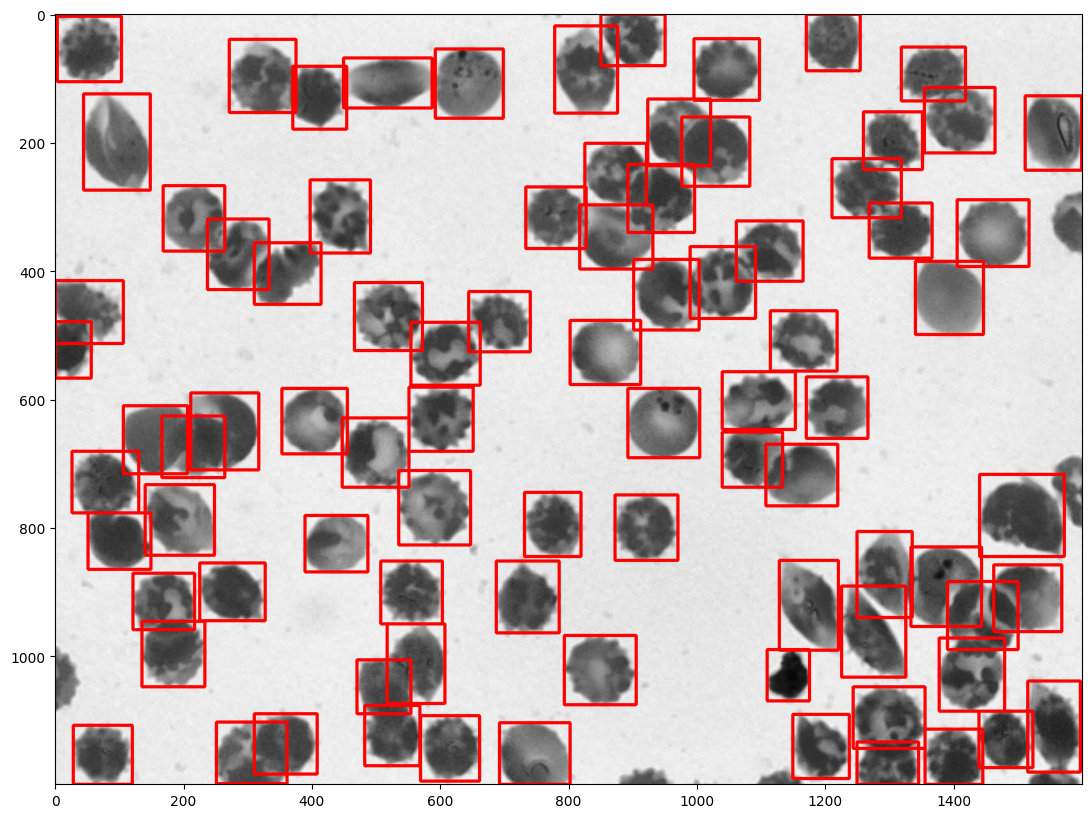

In [61]:
fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(image_cp)

In [62]:
from BloodCellDataset import slice_dataset, BloodCellDataset, PATCH_SIZE

# n = 256
# n = 1280
# n = 2048
n = 128
dataset = BloodCellDataset(
    orig_size=orig_size,
    # img_size=(PATCH_SIZE * 9, PATCH_SIZE * 12),  # orig size
    img_size=(PATCH_SIZE * 4, PATCH_SIZE * 5), # FIXME: cells are too big - fix paching/resizing logic
    n=n,
)
dataset.fit((bg_patches, bg_masks, cell_data, labeled_orig))

In [63]:
_, gray_img, _, num_cells, boxes = dataset[0]
gray_img

array([[219, 219, 220, ..., 221, 219, 218],
       [219, 220, 220, ..., 222, 220, 220],
       [220, 221, 221, ..., 222, 222, 221],
       ...,
       [222, 222, 221, ..., 222, 222, 222],
       [223, 222, 221, ..., 223, 222, 222],
       [223, 222, 221, ..., 223, 222, 221]], shape=(512, 640), dtype=uint8)

In [64]:
image_cp = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB).copy()
img_h, img_w = image_cp.shape[:2]
for i, (x, y, w, h) in enumerate(boxes):

    x = int(x * img_w)
    y = int(y * img_h)
    w = int(w * img_w)
    h = int(h * img_h)

    x1 = x - w // 2
    x2 = x + w // 2
    y1 = y - h // 2
    y2 = y + h // 2

    cv2.rectangle(image_cp, (x1 , y1), (x2, y2), (255, 0, 0), 3)

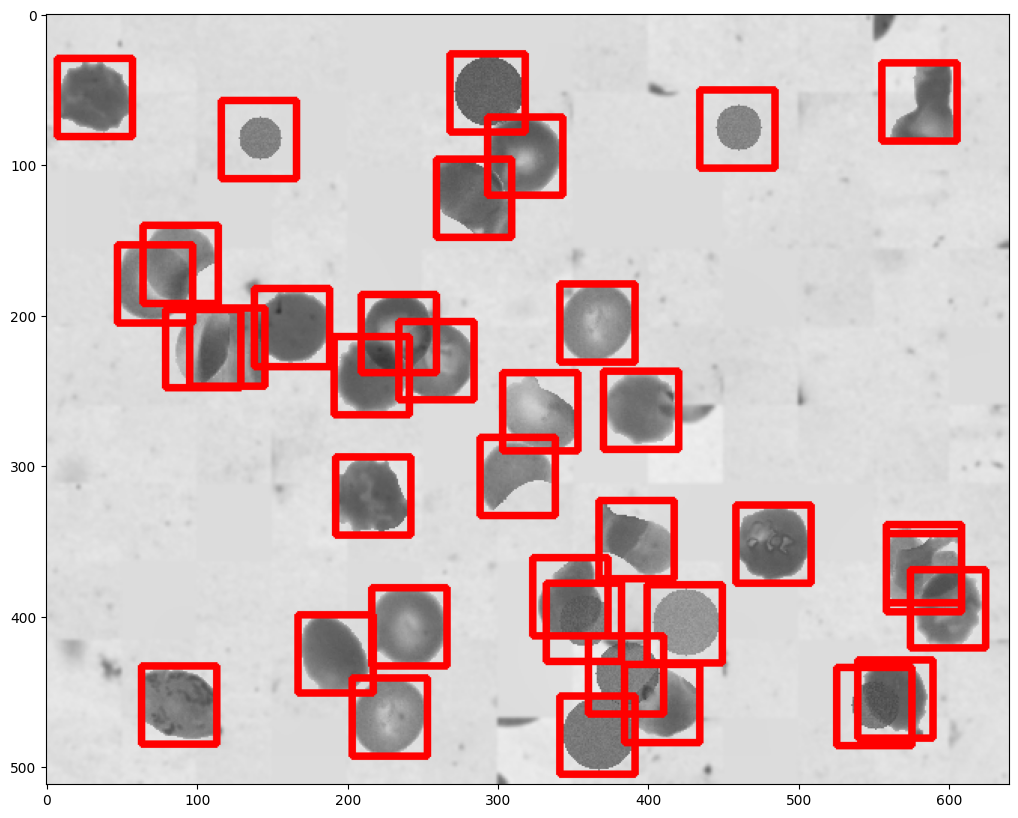

In [65]:
fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(image_cp)

In [66]:
class BloodCellTorchDataset(Dataset):
    def __init__(self, base_dataset_aug, base_dataset_real):
        self.base_dataset_aug = base_dataset_aug
        self.base_dataset_real = base_dataset_real
        self.data = {}

    def __len__(self):
        return len(self.base_dataset_aug) + len(self.base_dataset_real)

    def __getitem__(self, idx):
        if idx in self.data:
            return self.data[idx]
        
        if idx < len(self.base_dataset_real):
            gray_img, num_cells, boxes = self.base_dataset_real[idx]
        else:
            _, gray_img, _, num_cells, boxes = self.base_dataset_aug[idx]

        self.data[idx] = gray_img, boxes, num_cells
        return self.data[idx]


In [67]:
torch_dataset = BloodCellTorchDataset(dataset, labeled_orig)

In [68]:
train_set, val_set = torch.utils.data.random_split(
    torch_dataset, [0.8, 0.2]
)
len(train_set), len(val_set)

(183, 45)

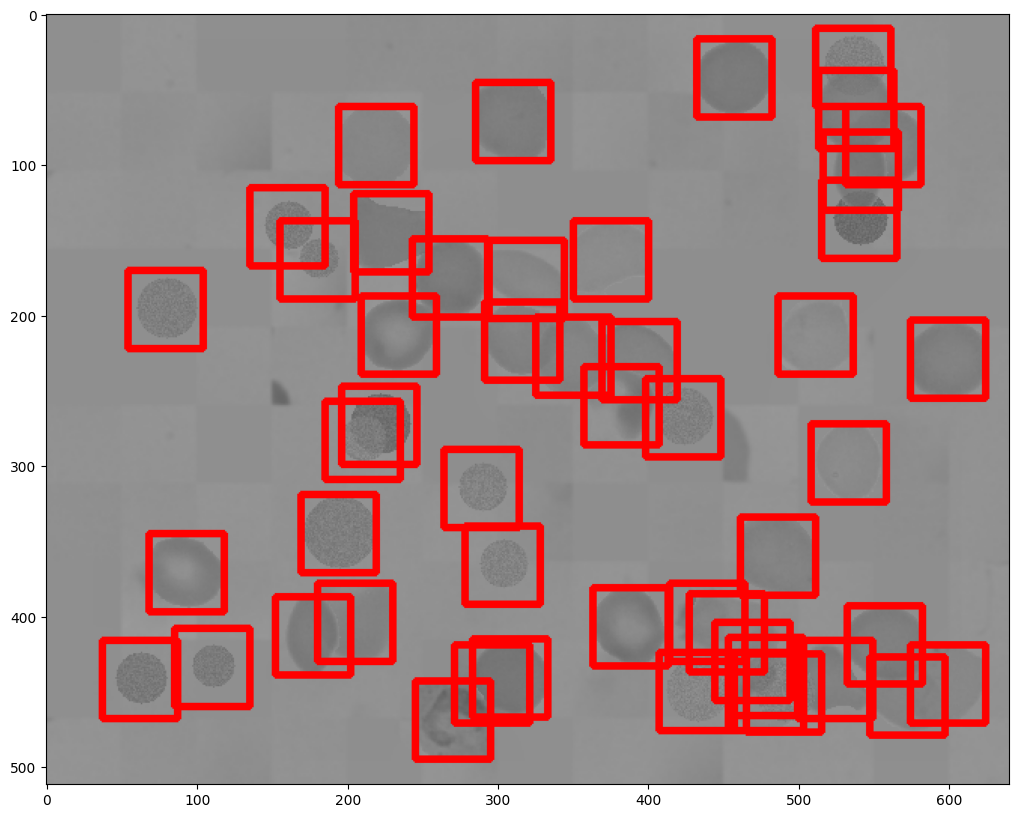

In [69]:
gray_img, boxes, num_cells = train_set[42]
image_cp = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB).copy()
img_h, img_w = image_cp.shape[:2]
for i, (x, y, w, h) in enumerate(boxes):

    x = int(x * img_w)
    y = int(y * img_h)
    w = int(w * img_w)
    h = int(h * img_h)

    x1 = x - w // 2
    x2 = x + w // 2
    y1 = y - h // 2
    y2 = y + h // 2

    cv2.rectangle(image_cp, (x1 , y1), (x2, y2), (255, 0, 0), 3)
fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(image_cp)

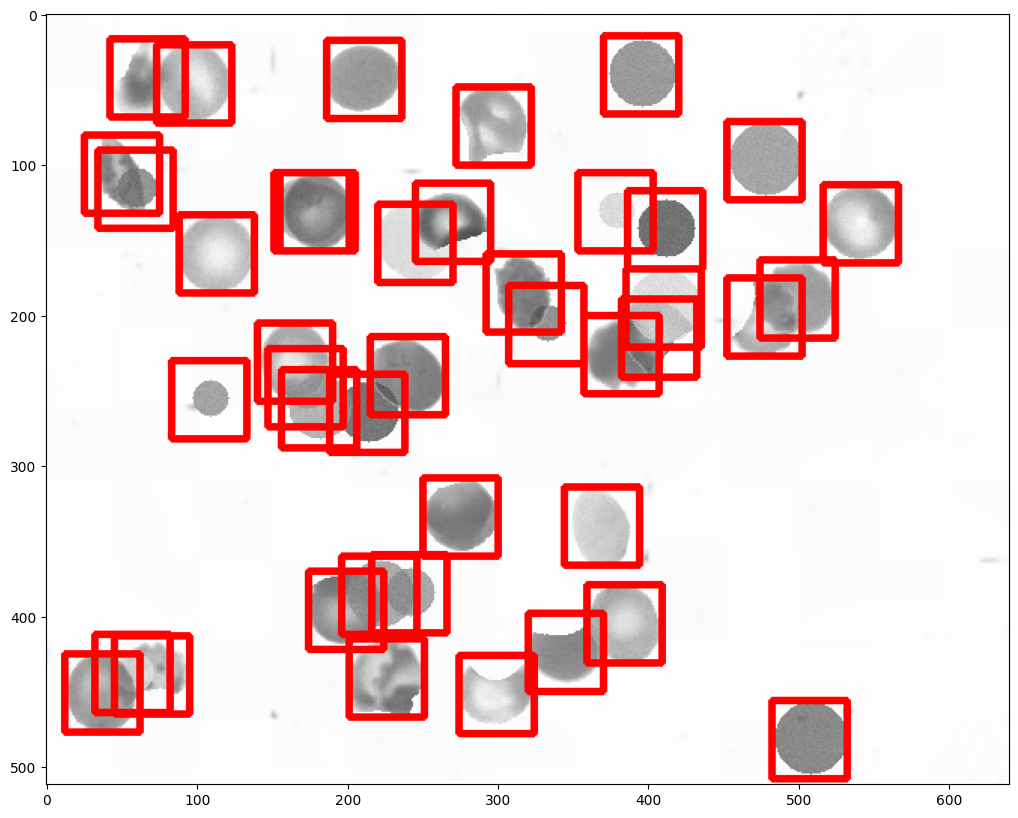

In [70]:
gray_img, boxes, num_cells = val_set[42]
image_cp = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB).copy()
img_h, img_w = image_cp.shape[:2]
for i, (x, y, w, h) in enumerate(boxes):

    x = int(x * img_w)
    y = int(y * img_h)
    w = int(w * img_w)
    h = int(h * img_h)

    x1 = x - w // 2
    x2 = x + w // 2
    y1 = y - h // 2
    y2 = y + h // 2

    cv2.rectangle(image_cp, (x1 , y1), (x2, y2), (255, 0, 0), 3)
fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(image_cp)

In [73]:
from pathlib import Path

output_dir = 'yolo_data_man'
output_dir = Path(output_dir)
img_dir = output_dir / "images"
label_dir = output_dir / "labels"

for split in ["train", "val"]:
    (img_dir / split).mkdir(parents=True, exist_ok=True)
    (label_dir / split).mkdir(parents=True, exist_ok=True)

split_name = "train"
for i, entry in enumerate(train_set):
    gray_img, boxes, num_cells = entry

    base_name = f"img_{i:05d}"
    gray_rgb = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB)

    cv2.imwrite(str(img_dir / split_name / f"{base_name}.jpg"), gray_rgb)

    yolo_lines = [f"0 {x:.6f} {y:.6f} {w:.6f} {h:.6f}" for (x, y, w, h) in boxes]

    with open(label_dir / split_name / f"{base_name}.txt", "w") as f:
        f.write("\n".join(yolo_lines))

split_name = "val"
for i, entry in enumerate(val_set):
    gray_img, boxes, num_cells = entry

    base_name = f"img_{i:05d}"
    gray_rgb = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB)

    cv2.imwrite(str(img_dir / split_name / f"{base_name}.jpg"), gray_rgb)

    yolo_lines = [f"0 {x:.6f} {y:.6f} {w:.6f} {h:.6f}" for (x, y, w, h) in boxes]

    with open(label_dir / split_name / f"{base_name}.txt", "w") as f:
        f.write("\n".join(yolo_lines))

In [74]:
import yaml

yaml_content = {
    "path": str(output_dir.absolute()),
    "train": "images/train",
    "val": "images/val",
    "names": {0: "blood_cell"},
}

yaml_path = output_dir / "dataset.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(yaml_content, f, sort_keys=False)

In [75]:
from ultralytics import YOLO

model_size="n"

model = YOLO(f"yolov8{model_size}.pt")

In [76]:
epochs = 20
imgsz = 640
batch = 16
project = "runs"
name = "blood_cells"

results = model.train(
    data=yaml_path,
    epochs=epochs,
    imgsz=imgsz,
    batch=batch,
    project=project,
    name=name,
    patience=20,
    save=True,
    plots=True,
    verbose=True,
)

Ultralytics 8.4.51  Python-3.12.10 torch-2.9.0+rocmsdk20251116 CUDA:0 (AMD Radeon RX 9060 XT, 16304MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_data_man\dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=blood_cells, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

In [ ]:
results = model.predict(source="yolo_data_man/images/val/img_00000.jpg")
count = len(results[0].boxes)
count


image 1/1 d:\code\notebooks\2d_graphics\yolo_data_man\images\val\img_00000.jpg: 512x640 68 blood_cells, 11.5ms
Speed: 1.3ms preprocess, 11.5ms inference, 1.7ms postprocess per image at shape (1, 3, 512, 640)


68

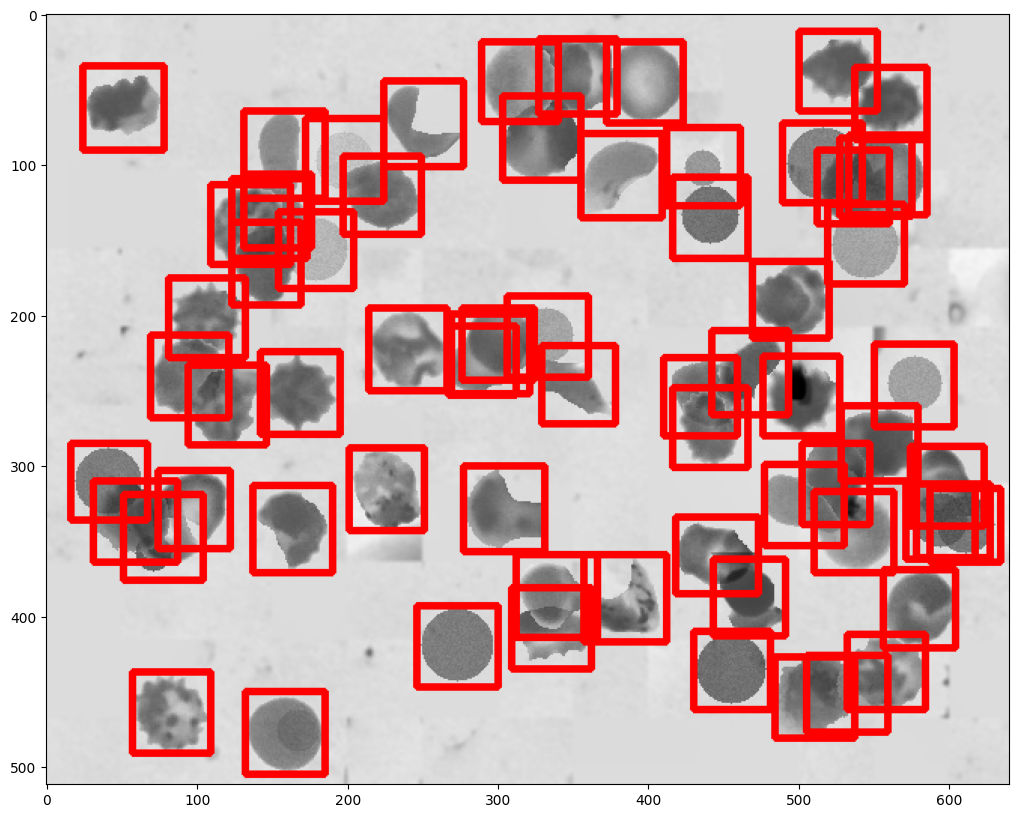

In [ ]:
boxes = results[0].boxes.data.cpu().numpy()
image_cp = cv2.imread("yolo_data_man/images/val/img_00000.jpg")
img_h, img_w = image_cp.shape[:2]
for i, box in enumerate(boxes):
    x1, y1, x2, y2, _, _ = box

    x1 = int(x1)
    y1 = int(y1)
    x2 = int(x2)
    y2 = int(y2)

    cv2.rectangle(image_cp, (x1 , y1), (x2, y2), (255, 0, 0), 3)
fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(image_cp)

65


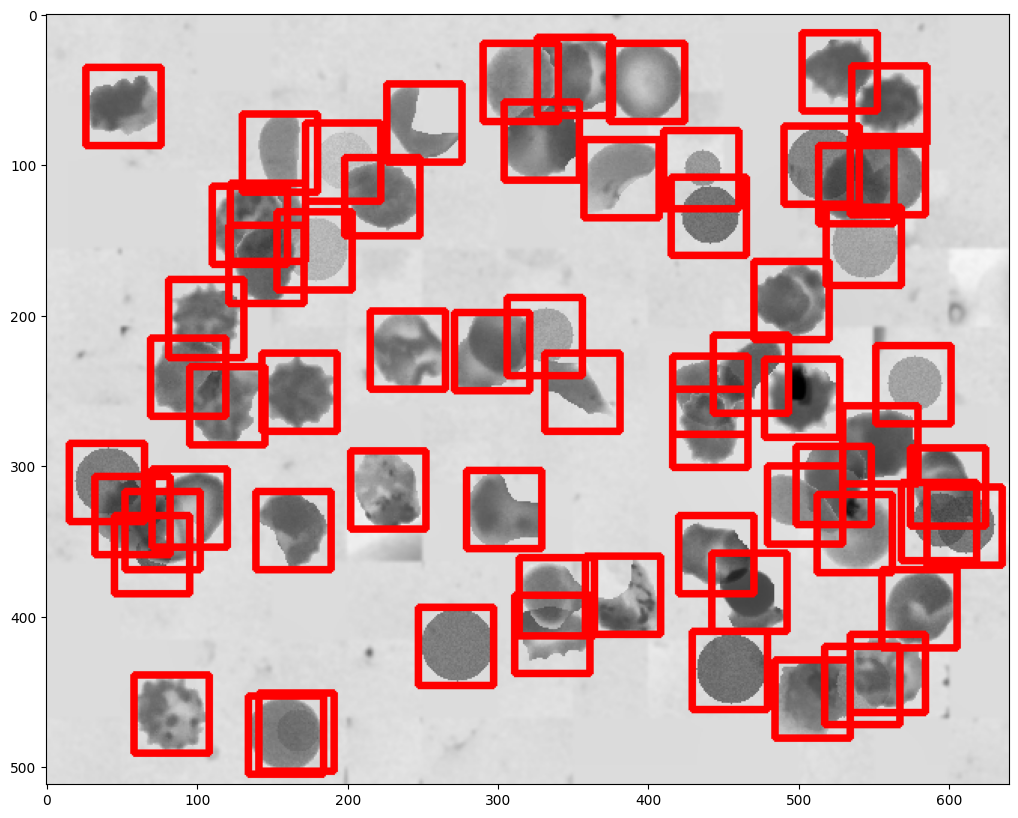

In [97]:
gray_img, boxes, num_cells = val_set[0]
print(num_cells)
image_cp = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB).copy()
img_h, img_w = image_cp.shape[:2]
for i, (x, y, w, h) in enumerate(boxes):

    x = int(x * img_w)
    y = int(y * img_h)
    w = int(w * img_w)
    h = int(h * img_h)

    x1 = x - w // 2
    x2 = x + w // 2
    y1 = y - h // 2
    y2 = y + h // 2

    cv2.rectangle(image_cp, (x1 , y1), (x2, y2), (255, 0, 0), 3)
fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(image_cp)

In [107]:
err = 0.0

split_name = "val"
for i, entry in enumerate(val_set):
    _, _, num_cells = entry

    base_name = f"img_{i:05d}"

    results = model.predict(source=str(img_dir / split_name / f"{base_name}.jpg"))
    count = len(results[0].boxes)

    err += abs(count - num_cells) / num_cells


image 1/1 d:\code\notebooks\2d_graphics\yolo_data_man\images\val\img_00000.jpg: 512x640 68 blood_cells, 14.0ms
Speed: 2.2ms preprocess, 14.0ms inference, 2.5ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 d:\code\notebooks\2d_graphics\yolo_data_man\images\val\img_00001.jpg: 512x640 40 blood_cells, 17.7ms
Speed: 1.9ms preprocess, 17.7ms inference, 1.9ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 d:\code\notebooks\2d_graphics\yolo_data_man\images\val\img_00002.jpg: 512x640 46 blood_cells, 12.3ms
Speed: 1.8ms preprocess, 12.3ms inference, 1.6ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 d:\code\notebooks\2d_graphics\yolo_data_man\images\val\img_00003.jpg: 512x640 110 blood_cells, 16.8ms
Speed: 1.7ms preprocess, 16.8ms inference, 1.7ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 d:\code\notebooks\2d_graphics\yolo_data_man\images\val\img_00004.jpg: 480x640 127 blood_cells, 11.8ms
Speed: 1.9ms preprocess, 11.8ms inference, 1.3ms p

In [108]:
err / len(val_set)

0.09000034478017058

In [ ]:
# rm -rf output_dir, runs